# SKCM Somatic MAF Analysis

## Project Overview

This notebook analyzes open-access somatic mutation data from TCGA-SKCM, the TCGA skin cutaneous melanoma cohort. The goal is to practice clinically oriented cancer genomics analysis using Mutation Annotation Format (MAF) data.

SKCM was selected because melanoma is highly relevant to immunotherapy, tumor mutational burden, immune escape, and molecular oncology biomarker development.

This project is for educational and portfolio purposes only. It is not intended for diagnosis, treatment decisions, or clinical reporting.

## Planned Workflow

1. Import Python packages.
2. Load open-access TCGA-SKCM MAF data.
3. Inspect the dataset structure.
4. Summarize the number of variants and tumor samples.
5. Summarize mutation classifications and variant types.
6. Identify frequently mutated genes.
7. Calculate mutation counts per sample as a simple tumor mutation burden-style proxy.
8. Flag selected melanoma- and immunotherapy-relevant genes.
9. Export summary tables and figures.
10. Document interpretation and limitations.

In [3]:
# Core packages
import pandas as pd
import numpy as np
from pathlib import Path

# Visualization
import matplotlib.pyplot as plt

# Display settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 50)

In [4]:
# Define project paths
project_dir = Path("..")
data_dir = project_dir / "data"
results_dir = project_dir / "results" / "skcm"

# Create results directory if it does not already exist
results_dir.mkdir(parents=True, exist_ok=True)

data_dir, results_dir

(WindowsPath('../data'), WindowsPath('../results/skcm'))

## Data Source

This project will use open-access TCGA-SKCM somatic mutation data from the NCI Genomic Data Commons (GDC).

The GDC describes MAF files as tab-delimited project-level files containing aggregated mutation information from VCF files. GDC somatic MAF files, also called Masked Somatic Mutation files, are open-access files that have been processed to remove lower-quality and potential germline variants.

Raw or large data files are not stored directly in this GitHub repository. Download instructions are documented in the project `data/README.md`.

In [5]:
# Directory containing downloaded SKCM MAF files
skcm_maf_dir = data_dir / "skcm_maf"

# Find all compressed MAF files
skcm_maf_files = sorted(skcm_maf_dir.rglob("*.maf.gz"))

print(f"Found {len(skcm_maf_files)} SKCM MAF files.")

Found 150 SKCM MAF files.


In [6]:
if len(skcm_maf_files) > 0:
    maf_list = []

    for file in skcm_maf_files:
        temp_maf = pd.read_csv(file, sep="\t", comment="#", low_memory=False)
        temp_maf["source_file"] = file.name
        maf_list.append(temp_maf)

    skcm_maf = pd.concat(maf_list, ignore_index=True)

    print(f"Loaded combined SKCM MAF with {skcm_maf.shape[0]:,} rows and {skcm_maf.shape[1]:,} columns.")
else:
    skcm_maf = None
    print(f"No MAF files found in: {skcm_maf_dir}")

Loaded combined SKCM MAF with 85,981 rows and 141 columns.


In [10]:
skcm_maf.head()

,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Variant_Classification,Variant_Type,Reference_Allele,Tumor_Seq_Allele1,Tumor_Seq_Allele2,dbSNP_RS,dbSNP_Val_Status,Tumor_Sample_Barcode,Matched_Norm_Sample_Barcode,Match_Norm_Seq_Allele1,Match_Norm_Seq_Allele2,Tumor_Validation_Allele1,Tumor_Validation_Allele2,Match_Norm_Validation_Allele1,Match_Norm_Validation_Allele2,Verification_Status,Validation_Status,Mutation_Status,Sequencing_Phase,Sequence_Source,Validation_Method,Score,BAM_File,Sequencer,Tumor_Sample_UUID,Matched_Norm_Sample_UUID,HGVSc,HGVSp,HGVSp_Short,Transcript_ID,Exon_Number,t_depth,t_ref_count,t_alt_count,n_depth,n_ref_count,n_alt_count,all_effects,Allele,Gene,Feature,Feature_type,...,gnomAD_ASJ_AF,gnomAD_EAS_AF,gnomAD_FIN_AF,gnomAD_NFE_AF,gnomAD_OTH_AF,gnomAD_SAS_AF,MAX_AF,MAX_AF_POPS,gnomAD_non_cancer_AF,gnomAD_non_cancer_AFR_AF,gnomAD_non_cancer_AMI_AF,gnomAD_non_cancer_AMR_AF,gnomAD_non_cancer_ASJ_AF,gnomAD_non_cancer_EAS_AF,gnomAD_non_cancer_FIN_AF,gnomAD_non_cancer_MID_AF,gnomAD_non_cancer_NFE_AF,gnomAD_non_cancer_OTH_AF,gnomAD_non_cancer_SAS_AF,gnomAD_non_cancer_MAX_AF_adj,gnomAD_non_cancer_MAX_AF_POPS_adj,CLIN_SIG,SOMATIC,PUBMED,TRANSCRIPTION_FACTORS,MOTIF_NAME,MOTIF_POS,HIGH_INF_POS,MOTIF_SCORE_CHANGE,miRNA,IMPACT,PICK,VARIANT_CLASS,TSL,HGVS_OFFSET,PHENO,GENE_PHENO,CONTEXT,tumor_bam_uuid,normal_bam_uuid,case_id,GDC_FILTER,COSMIC,hotspot,RNA_Support,RNA_depth,RNA_ref_count,RNA_alt_count,callers,source_file
0,PER3,8863,BI,GRCh38,chr1,7785510,7785510,+,Silent,SNP,C,C,T,rs375818157,NaN,TCGA-EB-A5SE-01A-11D-A30X-08,TCGA-EB-A5SE-10A-01D-A30X-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Somatic,NaN,NaN,NaN,NaN,NaN,NaN,55f628bc-f199-4eb0-9388-9945bf2deabd,5ee0cf3a-5e46-4644-af01-64abd1c26929,c.198C>T,p.Phe66=,p.F66=,ENST00000361923,2/21,59,32,27,53,NaN,NaN,"PER3,synonymous_variant,p.F66=,ENST00000613533...",T,ENSG00000049246,ENST00000361923,Transcript,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000116,EA,0.000027,0.000024,0.0,0.0,0.0,0.0,0.0,0.0,0.000046,0.0,0.0,0.000046,nfe,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LOW,NaN,SNV,1.0,NaN,NaN,1.0,TACTTCCCCTC,912ba95c-848d-4c12-ac7e-b37a6897cd6f,ed47855f-50a3-445d-9502-7078bbc39618,fda160c9-efdc-4263-98f1-e38b00571b4d,NaN,COSM3492540,N,Unknown,NaN,NaN,NaN,muse;mutect2;varscan2,4ea04f40-1608-49e6-925a-985ab6f6e863.wxs.aliqu...
1,ATP13A2,23400,BI,GRCh38,chr1,17005064,17005064,+,Silent,SNP,G,G,A,NaN,NaN,TCGA-EB-A5SE-01A-11D-A30X-08,TCGA-EB-A5SE-10A-01D-A30X-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Somatic,NaN,NaN,NaN,NaN,NaN,NaN,55f628bc-f199-4eb0-9388-9945bf2deabd,5ee0cf3a-5e46-4644-af01-64abd1c26929,c.297C>T,p.Ser99=,p.S99=,ENST00000326735,4/29,45,21,24,73,NaN,NaN,"ATP13A2,synonymous_variant,p.S99=,ENST00000326...",A,ENSG00000159363,ENST00000326735,Transcript,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LOW,1.0,SNV,1.0,NaN,1,1.0,TGCCAGGAACT,912ba95c-848d-4c12-ac7e-b37a6897cd6f,ed47855f-50a3-445d-9502-7078bbc39618,fda160c9-efdc-4263-98f1-e38b00571b4d,NaN,COSM3478465;COSM4904013,N,Unknown,NaN,NaN,NaN,muse;mutect2;varscan2,4ea04f40-1608-49e6-925a-985ab6f6e863.wxs.aliqu...
2,AKR7A3,22977,BI,GRCh38,chr1,19285108,19285108,+,Missense_Mutation,SNP,A,A,T,NaN,NaN,TCGA-EB-A5SE-01A-11D-A30X-08,TCGA-EB-A5SE-10A-01D-A30X-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Somatic,NaN,NaN,NaN,NaN,NaN,NaN,55f628bc-f199-4eb0-9388-9945bf2deabd,5ee0cf3a-5e46-4644-af01-64abd1c26929,c.514T>A,p.Tyr172Asn,p.Y172N,ENST00000361640,4/7,55,27,27,58,NaN,NaN,"AKR7A3,missense_variant,p.Y172N,ENST0000036164...",T,ENSG00000162482,ENST00000361640,Transcript,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MODERATE,1.0,SNV,1.0,NaN,1,NaN,ATTGTACATGC,912ba95c-848d-4c12-ac7e-b37a6897cd6f,ed47855f-50a3-445d-9502-7078bbc39618,fda160c9-efdc-4263-98f1-e38b00571b4d,NaN,NaN,N,Unknown,NaN,NaN,NaN,muse;mutect2;varscan2,4ea04f40-1608-49e6-925a-985ab6f6e863.wxs.aliqu...
3,AKR7A3

In [11]:
skcm_maf.shape

(85981, 141)

In [12]:
skcm_maf.columns.tolist()

['Hugo_Symbol',
 'Entrez_Gene_Id',
 'Center',
 'NCBI_Build',
 'Chromosome',
 'Start_Position',
 'End_Position',
 'Strand',
 'Variant_Classification',
 'Variant_Type',
 'Reference_Allele',
 'Tumor_Seq_Allele1',
 'Tumor_Seq_Allele2',
 'dbSNP_RS',
 'dbSNP_Val_Status',
 'Tumor_Sample_Barcode',
 'Matched_Norm_Sample_Barcode',
 'Match_Norm_Seq_Allele1',
 'Match_Norm_Seq_Allele2',
 'Tumor_Validation_Allele1',
 'Tumor_Validation_Allele2',
 'Match_Norm_Validation_Allele1',
 'Match_Norm_Validation_Allele2',
 'Verification_Status',
 'Validation_Status',
 'Mutation_Status',
 'Sequencing_Phase',
 'Sequence_Source',
 'Validation_Method',
 'Score',
 'BAM_File',
 'Sequencer',
 'Tumor_Sample_UUID',
 'Matched_Norm_Sample_UUID',
 'HGVSc',
 'HGVSp',
 'HGVSp_Short',
 'Transcript_ID',
 'Exon_Number',
 't_depth',
 't_ref_count',
 't_alt_count',
 'n_depth',
 'n_ref_count',
 'n_alt_count',
 'all_effects',
 'Allele',
 'Gene',
 'Feature',
 'Feature_type',
 'One_Consequence',
 'Consequence',
 'cDNA_position',
 'C

In [13]:
n_variants = skcm_maf.shape[0]
n_samples = skcm_maf["Tumor_Sample_Barcode"].nunique()
n_genes = skcm_maf["Hugo_Symbol"].nunique()

print(f"Number of variants: {n_variants:,}")
print(f"Number of tumor samples: {n_samples:,}")
print(f"Number of mutated genes: {n_genes:,}")

Number of variants: 85,981
Number of tumor samples: 150
Number of mutated genes: 15,176


In [14]:
mutation_class_counts = (
    skcm_maf["Variant_Classification"]
    .value_counts()
    .reset_index()
)

mutation_class_counts.columns = ["Variant_Classification", "Count"]
mutation_class_counts

,Variant_Classification,Count
0,Missense_Mutation,50901
1,Silent,27899
2,Nonsense_Mutation,3154
3,Intron,833
4,Splice_Site,710
5,Splice_Region,698
6,RNA,638
7,Frame_Shift_Del,292
8,3'UTR,205
9,5'Flank,129


In [15]:
variant_type_counts = (
    skcm_maf["Variant_Type"]
    .value_counts()
    .reset_index()
)

variant_type_counts.columns = ["Variant_Type", "Count"]
variant_type_counts

,Variant_Type,Count
0,SNP,85470
1,DEL,388
2,INS,119
3,ONP,2
4,TNP,2


In [16]:
top_mutated_genes = (
    skcm_maf["Hugo_Symbol"]
    .value_counts()
    .head(20)
    .reset_index()
)

top_mutated_genes.columns = ["Gene", "Mutation_Count"]
top_mutated_genes

,Gene,Mutation_Count
0,TTN,701
1,MUC16,454
2,DNAH5,196
3,PCLO,164
4,LRP1B,119
5,DNAH7,105
6,DNAH9,104
7,ANK3,103
8,FAT4,102
9,MGAM,102


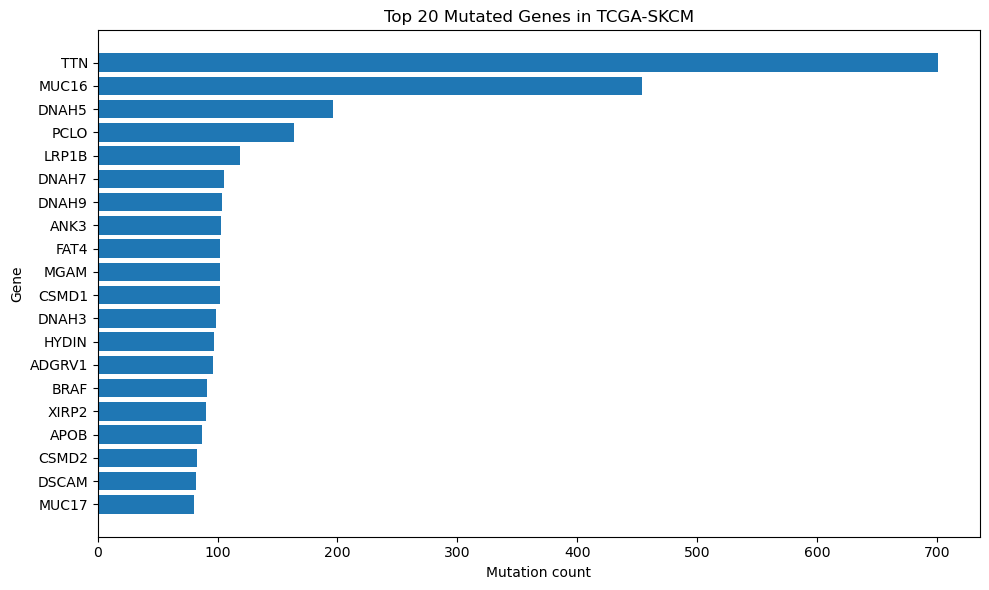

In [17]:
plt.figure(figsize=(10, 6))
plt.barh(top_mutated_genes["Gene"], top_mutated_genes["Mutation_Count"])
plt.gca().invert_yaxis()
plt.xlabel("Mutation count")
plt.ylabel("Gene")
plt.title("Top 20 Mutated Genes in TCGA-SKCM")
plt.tight_layout()
plt.show()

In [18]:
mutation_counts_per_sample = (
    skcm_maf
    .groupby("Tumor_Sample_Barcode")
    .size()
    .reset_index(name="Mutation_Count")
    .sort_values("Mutation_Count", ascending=False)
)

mutation_counts_per_sample.head(20)

,Tumor_Sample_Barcode,Mutation_Count
113,TCGA-FR-A726-01A-11D-A32N-08,8473
130,TCGA-GN-A266-06A-11D-A197-08,4657
149,TCGA-Z2-A8RT-06A-11D-A372-08,3507
94,TCGA-EE-A3J5-06A-11D-A20D-08,2584
87,TCGA-EE-A20C-06A-11D-A196-08,2516
148,TCGA-YG-AA3N-01A-11D-A38G-08,2442
47,TCGA-EB-A41A-01A-11D-A24R-08,2253
52,TCGA-EB-A431-01A-11D-A25O-08,2086
133,TCGA-GN-A26C-01A-11D-A19A-08,2060
23,TCGA-D3-A5GO-06A-12D-A27K-08,1889


In [19]:
mutation_counts_per_sample["Mutation_Count"].describe()

count     150.000000
mean      573.206667
std       941.645128
min         6.000000
25%       101.000000
50%       325.000000
75%       605.500000
max      8473.000000
Name: Mutation_Count, dtype: float64

In [20]:
skcm_genes_of_interest = [
    "BRAF", "NRAS", "NF1", "KIT", "PTEN", "TP53", "CDKN2A",
    "B2M", "JAK1", "JAK2", "HLA-A", "HLA-B", "HLA-C"
]

skcm_gene_subset = skcm_maf[
    skcm_maf["Hugo_Symbol"].isin(skcm_genes_of_interest)
].copy()

skcm_gene_summary = (
    skcm_gene_subset
    .groupby("Hugo_Symbol")
    .size()
    .reset_index(name="Mutation_Count")
    .sort_values("Mutation_Count", ascending=False)
)

skcm_gene_summary

,Hugo_Symbol,Mutation_Count
1,BRAF,91
8,NF1,32
9,NRAS,31
11,TP53,22
2,CDKN2A,14
10,PTEN,13
7,KIT,7
5,JAK1,5
6,JAK2,4
0,B2M,2
